# Atividade sobre rede neural profunda

Objetivos:
1. Dataset: Para iniciar, vocês devem utilizar o dataset Fashion MNIST, disponível no Kaggle através do link:

    [Kaggle - Fashion MNIST](https://www.kaggle.com/datasets/zalando-research/fashionmnist/data)

2. Importação: Lembrem-se de utilizar os comandos de integração e importação que aprendemos e executamos em nosso último encontro.

3. Foco na Experimentação: O objetivo principal é a prática com a arquitetura do modelo. Esperamos que vocês testem diferentes configurações e observem como a rede se comporta. Fiquem livres para "brincar" com a estrutura:

    * Alterem a quantidade de camadas ocultas;
    * Aumentem ou diminuam o número de neurônios;
    * Busquem a melhor taxa de acerto (accuracy) possível para o problema.



## Fazendo download do DS

> Usando comando que o kaggle disponibiliza

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zalando-research/fashionmnist")

print("Path to dataset files:", path)

## Entendendo o nosso dataset

Lendo o .csv usando a biblioteca pandas, e vizualizando o formato e estado do nosso conjunto de dados

In [ ]:
import pandas as pd
import os

train_ds = pd.read_csv(os.path.join(path, "fashion-mnist_train.csv"))
test_ds = pd.read_csv(os.path.join(path, "fashion-mnist_test.csv"))

print(len(train_ds), len(test_ds))

print(train_ds.shape)

print(train_ds.head())

## Separando Dataset

Como visto na célula anterior nosso dataset não possui separação de labels e imagens e está com o formato errado.

Vamos corrigir isso separando as colunas referente a labels e pixels e ajustando o shape dos vetores.

In [ ]:
train_labels = train_ds['label'].values
train_imgs = train_ds.drop('label', axis=1).values

test_labels = test_ds['label'].values
test_imgs = test_ds.drop('label', axis=1).values

print(train_imgs.shape)

print(train_imgs)

train_imgs = train_imgs.reshape(60000, 28, 28)
test_imgs = test_imgs.reshape(10000, 28, 28)

print(train_imgs.shape)
print(train_imgs[0])

## Vizualizando o nosso Dataset

Agora que tudo está em formato padrão, vamos vizualizar o nosso dataset para ver se está correto mesmo.

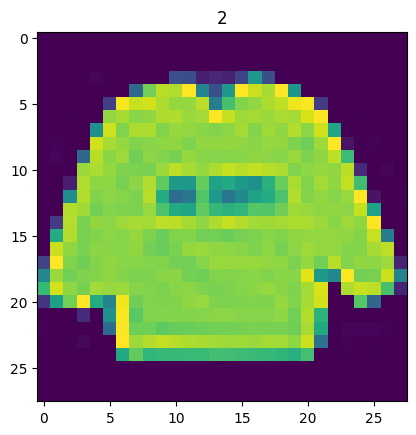

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(train_imgs[0]) # troque '0' pela posição da imagem que deseja ver
plt.title(train_labels[0]) # troque '0' pela posição da label que deseja ver
plt.show()

## Mapa das classes em portugues

> possível pegar no github https://github.com/zalandoresearch/fashion-mnist


In [ ]:
classes_names = [
    'Camiseta',
    'Calça',
    'Pullover',
    'Vestido',
    'Casaco',
    'Sandália',
    'Camisa',
    'Tênis',
    'Bolsa',
    'Bota'
]

# Normalização dos pixels das nossas imagens

Normalização dos pixels da imagem de 0-255 para valores de 0-1

Motivo: Valores menores fazem com que a rede tenha uma convergência mais eficiente durante o treinamento

In [ ]:
train_imgs = train_imgs/255
test_imgs = test_imgs/255

## Instânciando a rede

Criando todas as camadas da nossa rede de aprendizado profundo

> Sem usar convolução

In [ ]:
import tensorflow
from keras import layers, models

model = models.Sequential(
    [
        # Camada de compressão para vetor de 784 números
        layers.Flatten(input_shape=(28,28)),

        layers.Dense(1024, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4), # Apaga 40% dos neurônios

        # 2ª Camada Oculta
        layers.Dense(1024, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # 3ª Camada Oculta
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        # 4ª Camada Oculta
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        # 5ª Camada Oculta
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        # 4ª Camada Oculta
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        # Saída para as 10 categorias de roupas
        layers.Dense(10, activation='softmax')
    ]
)

# Compilação do modelo
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'] # adicionar métrica para vizulizar no gráfico
)

## Print do resumo do nosso modelo

Aqui podemos avaliar cada camada do nosso modelo depois de compilado

In [ ]:
summary_model = model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 571,018 (2.18 MB)

 Trainable params: 569,226 (2.17 MB)

 Non-trainable params: 1,792 (7.00 KB)

## Treinamento do modelo

Relizando o treinamento do modelo, é importante colocar um número de épocas (epochs) suficiente para que o modelo apresente uma boa conversão.

> Dica: Tamanhos de batch maiores ajudam o modelo no BatchNormalization

In [ ]:
train_stats = model.fit(train_imgs,
          train_labels,
          epochs=20,
          batch_size=128,
          validation_split=0.2
          )

## Avaliando modelo

Print da acurácia e da perda final no conjunto de teste

In [ ]:
test_loss, test_accuracy = model.evaluate(test_imgs, test_labels)

print(f"Acurácia no conjunto de teste: {test_accuracy}")
print(f"Perda no conjunto de teste: {test_loss}")

### Gráfico de Acurácia e Loss

Avaliando over e underfitting do nosso modelo.

- **underfitting:** A linha de perda (loss) fica alta e não desce muito, e a acurácia (accuracy) fica baixa desde o início e não sobe.
  - **Solução:** Aumentar o cérebro da rede ou treinar por mais tempo.
- **overfitting:** A linha de loss de treino continua caindo em direção a zero, e a acurácia de treino vai para 99%. Porém, a linha de val_loss (validação) para de cair e começa a subir, e a val_accuracy estagna ou piora.
  - **Solução:** Aumentar o a diversidade do dataset ( data augmentation), forçar a rede a trabalhar com menos neuronios (dropout).


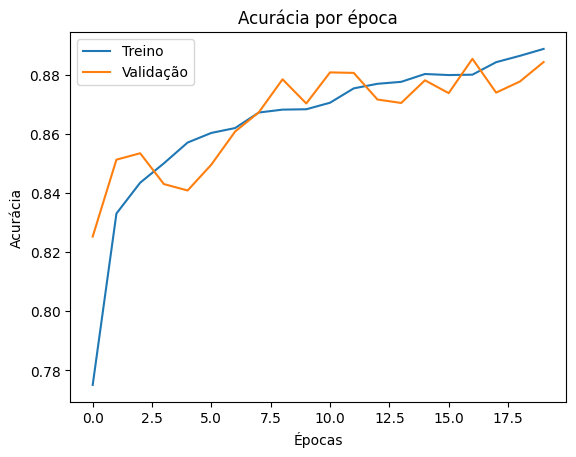

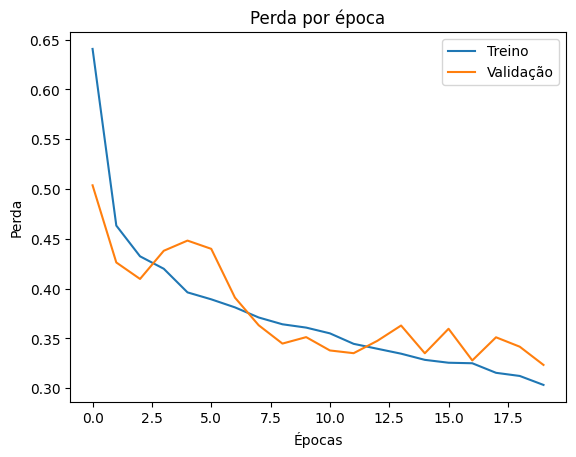

In [ ]:
plt.plot(train_stats.history['accuracy'])
plt.plot(train_stats.history['val_accuracy'])
plt.title('Acurácia por época')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend(['Treino', 'Validação'])
plt.show()

plt.plot(train_stats.history['loss'])
plt.plot(train_stats.history['val_loss'])
plt.title('Perda por época')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend(['Treino', 'Validação'])
plt.show()

# Rede CNN

In [ ]:
model_cnn = models.Sequential([
    # A imagem entra preservando sua geometria 2D (28x28 com 1 canal de cor)
    layers.Input(shape=(28, 28, 1)),

    # Extração de Características
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.4),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.4),

    # Classificação
    layers.Flatten(),
    layers.Dense(64, activation='relu'), # Apenas 64 neurônios aqui!
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Sumário
model_cnn.summary()

# Treinamento do modelo
train_cnn_stats = model_cnn.fit(train_imgs,
          train_labels,
          epochs=20,
          batch_size=128,
          validation_split=0.2
          )

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,250 (477.54 KB)

 Non-trainable params: 320 (1.25 KB)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 73s 183ms/step - accuracy: 0.7834 - loss: 0.6149 - val_accuracy: 0.8572 - val_loss: 0.3963
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 71s 189ms/step - accuracy: 0.8494 - loss: 0.4189 - val_accuracy: 0.8756 - val_loss: 0.3426
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 80s 183ms/step - accuracy: 0.8647 - loss: 0.3724 - val_accuracy: 0.8764 - val_loss: 0.3260
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 67s 180ms/step - accuracy: 0.8706 - loss: 0.3503 - val_accuracy: 0.8829 - val_loss: 0.3055
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 71s 188ms/step - accuracy: 0.8782 - loss: 0.3310 - val_accuracy: 0.8982 - val_loss: 0.2767
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 68s 181ms/step - accuracy: 0.8827 - loss: 0.3156 - val_accuracy: 0.8936 - val_loss: 0.2869
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 82s 181ms/step - accuracy: 0.8871 - loss: 0.3068 - val_accuracy: 0.8982 - val_loss: 0.2744
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 68s 182ms/step - accuracy: 0.8900 - loss: 0

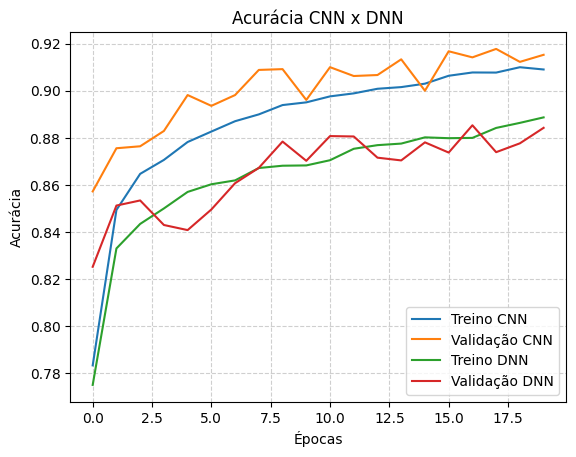

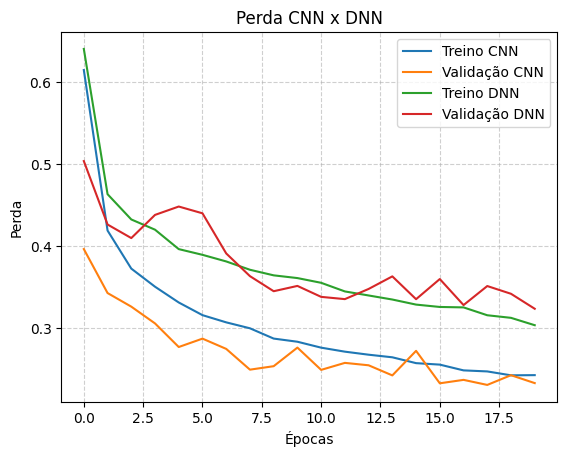

In [ ]:

# --- Gráfico 1: Acurácia ---
plt.plot(train_cnn_stats.history['accuracy'], label='Treino CNN')
plt.plot(train_cnn_stats.history['val_accuracy'], label='Validação CNN')
plt.plot(train_stats.history['accuracy'], label='Treino DNN')
plt.plot(train_stats.history['val_accuracy'], label='Validação DNN')
plt.title('Acurácia CNN x DNN')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- Gráfico 2: Perda (Loss) ---
plt.plot(train_cnn_stats.history['loss'], label='Treino CNN')
plt.plot(train_cnn_stats.history['val_loss'], label='Validação CNN')
plt.plot(train_stats.history['loss'], label='Treino DNN')
plt.plot(train_stats.history['val_loss'], label='Validação DNN')
plt.title('Perda CNN x DNN')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
